# 38 - Daughter nodes placed by born fraction

nb37 found the strategy-5 grid error at large f̃ converges at second order, but only 17 of the default 71 nodes
fall inside the birth window and 37 come after it. Each node is born at once, so during the window the daughter
appears as a staircase of ~17 steps. `accdm_q_log_share` = s (spec `2026-10-05-accdm-born-fraction-nodes-design`)
places the nodes evenly in

$$u(\ln a) = s\,\frac{\ln a - \ln a_{\min}}{\ln(1/a_{\min})} + (1-s)\,\frac{F(a) - F_{\min}}{1 - F_{\min}},$$

so a share 1 − s of them follows the born fraction F, with Simpson weights in u. s = 1 is the old grid; the
number of nodes, and so the cost, does not change.

- **0** counts the nodes inside the birth window for each s (no CLASS).
- **1** runs s = 0.6, 0.4, 0.25 at 50 and 100 bins/decade on nb37's (mass, f̃) points and compares Δχ² against
  nb37's 400/decade references, read from `37_cache.pkl` (both grids converge to the same limit).
- **2** checks the spec's success criteria at equal node count: Δχ² at least 10× smaller wherever the old grid
  was above 0.1, no point worse by more than the 0.04 floor (nb33, nb37), runtime within 10%.

Settings, Δχ² and tolerance as nb37. Runtime about 35 min (120 new runs); cached in `38_cache.pkl`.

In [1]:
import json
import multiprocessing as mp
import pickle
import queue
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


def show(df, formats):
    """display df with per-column format strings; missing values as '-'."""
    out = df.copy().astype(object)
    for col, f in formats.items():
        out[col] = [('-' if pd.isna(v) else f.format(v)) for v in df[col]]
    display(out)


CHAINS = find_root()/'chains'/'fixed_masses'/'connect'/'new'
BF = read_bestfit(CHAINS/'14'/'14.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}
OMEGA_DM_TOT = BF['omega_dm_tot']
KAPPA, A_T = 12.1, 0.133

# extra_input of the fixed-mass CONNECT emulators (as nb36); mass, f_tilde and precision are set per run
SETTINGS = {'k_pivot': 0.05, 'lensing': 'yes', 'N_ur': 2.0308, 'N_ncdm': 2, 'deg_ncdm': '1, 1',
            'm_ncdm': '0.06, 0.01', 'T_ncdm': '0.71611, 1.0', 'ncdm_quadrature_strategy': '0, 5',
            'ncdm_fluid_approximation': 3, 'kappa_acc': KAPPA, 'a_t_acc': A_T,
            'vary_Gamma_acc': 'yes', 'gauge': 'synchronous', 'reionization_z_start_max': 80,
            'evolver': 0, 'P_k_max_1/Mpc': 1., 'output': 'tCl,pCl,lCl,mPk', 'l_max_scalars': 2508,
            'omega_dm_tot': OMEGA_DM_TOT}


def per_decade(n):
    return {'accdm_q_bins_per_decade': n}


BINS = [50, 100, 200, 400]                    # 50 is the default
REF = 400
F_NULL = 1e-6                                 # signal reference; accDM needs f > 0
print('fiducial omega_dm_tot = {:.5f}'.format(OMEGA_DM_TOT))


def chain_f95(directory, burn_in=0.3):
    """95% upper limit on f_tilde of one connect/new chain, as sampled (flat omega_dm_tot, f_acc)."""
    names = [line.split()[0] for line in open(next(directory.glob('*_.paramnames')))]
    blocks = []
    for path in sorted(directory.glob('*__*.txt')):
        block = pd.read_csv(path, sep=r'\s+', header=None, comment='#').to_numpy()
        blocks.append(block[int(burn_in*len(block)):])
    data = np.vstack(blocks)
    w, f = data[:, 0], data[:, 2 + names.index('f_acc')]
    ft = f/(1 + f)
    order = np.argsort(ft)
    cdf = np.cumsum(w[order])
    return float(np.interp(0.95*cdf[-1], cdf, ft[order]))


F95 = {float(d.name): chain_f95(d) for d in CHAINS.iterdir() if d.is_dir() and d.name.replace('.', '').isdigit()
       and any(d.glob('*__*.txt'))}
print('chain 95% f_tilde:', ', '.join('{:g}: {:.3f}'.format(m, F95[m]) for m in sorted(F95)))

SHARES = [0.6, 0.4, 0.25]
NODE_BINS = [50, 100]

/opt/homebrew/Caskroom/miniforge/base/envs/accDM/lib/python3.12/site-packages/figkit/style.py:132: RuntimeWarning: text.usetex requested but latex, dvipng not found on PATH; falling back to matplotlib mathtext. Install TeX Live or MiKTeX (and dvipng) for identical output, or pass usetex=False to silence this.
  usetex = bool(usetex) and latex_available()


fiducial omega_dm_tot = 0.11771
chain 95% f_tilde: 11: 0.007, 12: 0.012, 13: 0.017, 14: 0.026, 15: 0.079, 15.301: 0.122, 15.699: 0.302, 16: 0.844, 16.301: 0.900, 16.699: 0.904, 17: 0.905, 17.301: 0.905, 17.699: 0.904, 18: 0.889


## 0. Nodes in the birth window

The same map as `background_acc_q_nodes`, evaluated on a fine ln a grid: q_size, and the nodes inside the central
98% and 80% of births. The plot shows the 50/decade nodes over the birth rate dF/dln a.

q_size  nodes in 1-99% of births  nodes in 10-90%  \
share bins/decade                                                      
1.00  50               71                        17                8   
      100             139                        33               16   
0.60  50               71                        37               27   
      100             139                        74               54   
0.40  50               71                        48               37   
      100             139                        94               72   
0.25  50               71                        56               44   
      100             139                       110               87   

                   nodes after 99%  
share bins/decade                   
1.00  50                        37  
      100                       72  
0.60  50                        23  
      100                       44  
0.40  50                        15  
      100                       30  
0.25  50                        10  
      100                       19

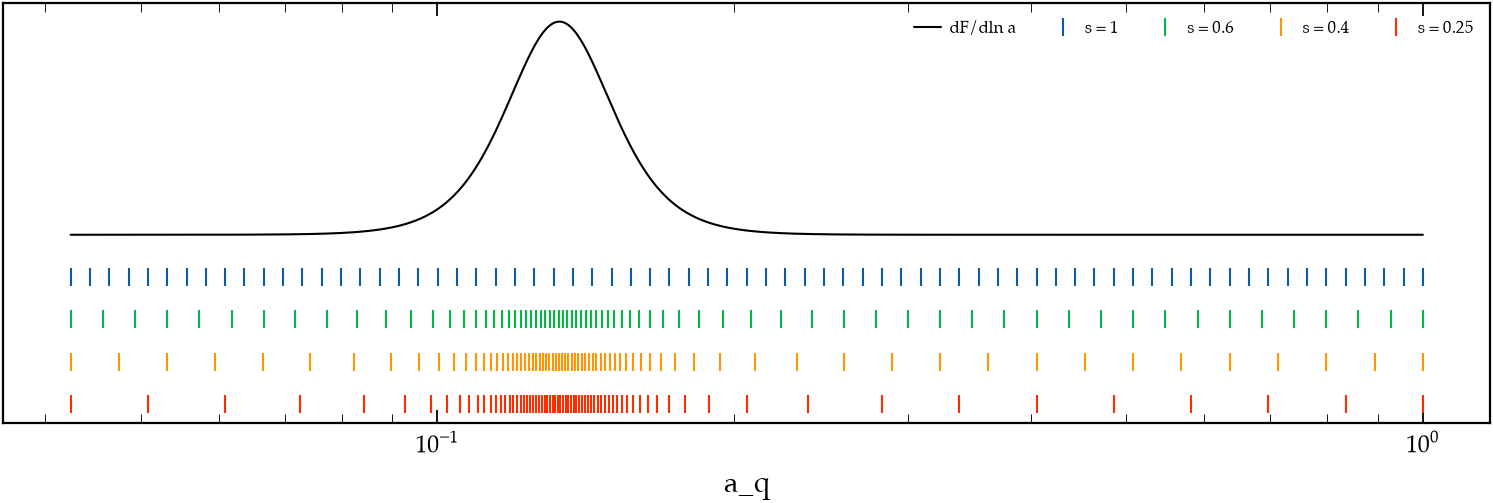

In [2]:
def born_fraction(a):
    """F(a) as in background_acc_born_fraction."""
    return 1 - (1 - a**KAPPA)/(1 + (a/A_T)**KAPPA)


def a_min(eps=1e-6):
    """background_acc_a_min: bisection in ln a."""
    lo, hi = np.log(1e-14), 0.0
    for _ in range(200):
        mid = 0.5*(lo + hi)
        lo, hi = (mid, hi) if born_fraction(np.exp(mid)) < eps else (lo, mid)
    return np.exp(lo)


A_MIN = a_min()
L = np.log(1/A_MIN)
F_MIN = born_fraction(A_MIN)
lna_fine = np.linspace(np.log(A_MIN), 0, 100001)
F_fine = born_fraction(np.exp(lna_fine))


def node_lna(share, per_dec):
    q_size = max(3, int(np.ceil(per_dec*np.log10(1/A_MIN))) + 1)
    q_size += q_size % 2 == 0
    u = share*(lna_fine - lna_fine[0])/L + (1 - share)*(F_fine - F_MIN)/(1 - F_MIN)
    return np.interp(np.linspace(0, 1, q_size), u, lna_fine)


rows = []
for share in [1.0] + SHARES:
    for n in NODE_BINS:
        F = born_fraction(np.exp(node_lna(share, n)))
        rows.append({'share': share, 'bins/decade': n, 'q_size': len(F),
                     'nodes in 1-99% of births': int(np.sum((F > 0.01) & (F < 0.99))),
                     'nodes in 10-90%': int(np.sum((F > 0.1) & (F < 0.9))),
                     'nodes after 99%': int(np.sum(F >= 0.99))})
display(pd.DataFrame(rows).set_index(['share', 'bins/decade']))

fig, ax = plt.subplots(figsize=(10, 3.4), constrained_layout=True)
ax.plot(np.exp(lna_fine), np.gradient(F_fine, lna_fine), 'k', lw=1, label='dF/dln a')
for j, share in enumerate([1.0] + SHARES):
    a_nodes = np.exp(node_lna(share, 50))
    ax.plot(a_nodes, np.full_like(a_nodes, -0.6*(j + 1)), '|', ms=9, label='s = {:g}'.format(share))
ax.set_xscale('log')
ax.set_xlabel('a_q')
ax.set_yticks([])
ax.legend(fontsize=8, ncol=5)
plt.show()

## 1. Δχ² against the 400/decade references

Old-grid runs (s = 1) and references come from nb37's cache; only the s < 1 runs are new.

In [3]:
LMAX = 2500
ELL = np.arange(2, LMAX + 1)
KK = np.logspace(-4, np.log10(0.9), 300)                             # 1/Mpc, inside P_k_max
Z_BAO = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])  # DESI DR2 effective z
TIMEOUT = 1800.0                                                     # s per run
CACHE = Path('38_cache.pkl')
cache = pickle.loads(CACHE.read_bytes()) if CACHE.exists() else {}


def params(log10m, f_tilde, **extra):
    return {**LCDM, **SETTINGS, 'm_acc_in_GeV': 10.0**log10m, 'f_tilde': f_tilde, **extra}


def run(p):
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['pk_cb'] = np.array([cosmo.pk_cb(k, 0.0) for k in KK])
        rd = cosmo.rs_drag()
        out['DM_rd'] = np.array([cosmo.angular_distance(z)*(1 + z) for z in Z_BAO])/rd
        out['DH_rd'] = np.array([1/cosmo.Hubble(z) for z in Z_BAO])/rd
        out['sigma8_cb'] = cosmo.sigma8_cb()
        out['T_cmb'] = cosmo.T_cmb()
        bg = cosmo.get_background()
        out['Omega_acc'] = bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1]
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    out['finite'] = bool(all(np.all(np.isfinite(v)) for v in out.values()))
    return out


def _child(p, q):
    try:
        q.put(run(p))
    except Exception as err:
        q.put({'error': '{}: {}'.format(type(err).__name__, err)})


def run_isolated(p):
    """run(p) in a forked child, so a crash or hang becomes an error entry."""
    ctx = mp.get_context('fork')
    q = ctx.Queue()
    proc = ctx.Process(target=_child, args=(p, q))
    t0 = time.time()
    proc.start()
    out = None
    while out is None:
        try:
            out = q.get(timeout=1.0)
        except queue.Empty:
            if not proc.is_alive():
                try:
                    out = q.get(timeout=2.0)
                except queue.Empty:
                    out = {'error': 'CLASS process died, exit code {}'.format(proc.exitcode)}
            elif time.time() - t0 > TIMEOUT:
                proc.kill()
                out = {'error': 'timeout after {:.0f} s'.format(TIMEOUT)}
    proc.join()
    out['sec'] = time.time() - t0
    return out


def cached_run(p):
    key = json.dumps(p, sort_keys=True)
    if key not in cache:
        cache[key] = run_isolated(p)
        CACHE.write_bytes(pickle.dumps(cache))
    return cache[key]


def ok(out):
    return 'error' not in out and out['finite']


# nb33 Delta chi2
FSKY = 0.6
ARCMIN = np.pi/(180*60)
BEAM, NOISE_T, NOISE_P = 7.0*ARCMIN, 33.0*ARCMIN, 70.0*ARCMIN    # beam in rad, noise in uK rad
SIGMA_LENS = 0.025
SIGMA_BAO = 0.01
L_LENS = (ELL >= 8) & (ELL <= 400)
DCHI2_TOL = 0.1


def noise_cl(sigma, t_cmb):
    """Beam-deconvolved white noise in the dimensionless units of lensed_cl."""
    return (sigma/(t_cmb*1e6))**2*np.exp(ELL*(ELL + 1)*BEAM**2/(8*np.log(2)))


def chi2_parts(a, b):
    """Approximate delta chi2 of run a against run b, per probe."""
    tt = b['tt'] + noise_cl(NOISE_T, b['T_cmb'])
    ee = b['ee'] + noise_cl(NOISE_P, b['T_cmb'])
    te = b['te']
    d = np.array([a['tt'] - b['tt'], a['ee'] - b['ee'], a['te'] - b['te']]).T
    cov = np.array([[2*tt**2, 2*te**2, 2*tt*te],
                    [2*te**2, 2*ee**2, 2*ee*te],
                    [2*tt*te, 2*ee*te, tt*ee + te**2]])/((2*ELL + 1)*FSKY)
    x = np.linalg.solve(np.moveaxis(cov, 2, 0), d[:, :, None])[:, :, 0]
    cmb = float(np.sum(d*x))
    w = (2*ELL + 1)[L_LENS]
    a_lens = np.sum(w*(a['pp']/b['pp'] - 1)[L_LENS])/np.sum(w)
    lens = float((a_lens/SIGMA_LENS)**2)
    bao = float(np.sum((a['DM_rd']/b['DM_rd'] - 1)**2 + (a['DH_rd']/b['DH_rd'] - 1)**2)/SIGMA_BAO**2)
    return {'total': cmb + lens + bao, 'cmb': cmb, 'lens': lens, 'bao': bao}


def compare(a, b):
    """Delta chi2 parts, max |dP_cb/P_cb|, d sigma8_cb and d Omega_acc of run a against run b."""
    return {**chi2_parts(a, b), 'dpk': float(np.max(np.abs(a['pk_cb']/b['pk_cb'] - 1))),
            'dsigma8': a['sigma8_cb']/b['sigma8_cb'] - 1, 'domega': a['Omega_acc']/b['Omega_acc'] - 1}


cache37 = pickle.loads(Path('37_cache.pkl').read_bytes())
hits37 = 0


def lookup(p):
    """nb37's run for these exact parameters, or a new cached run."""
    global hits37
    key = json.dumps(p, sort_keys=True)
    if key in cache37:
        hits37 += 1
        return cache37[key]
    return cached_run(p)

In [4]:
MASSES = [11, 12, 14, 16, 18]
F_GRID = [0.01, 0.1, 0.5, 0.9]

null = lookup(params(14, F_NULL))
assert ok(null), null.get('error')
ref, grid = {}, {}
for lm in MASSES:
    for ft in F_GRID:
        ref[(lm, ft)] = lookup(params(lm, ft, **per_decade(REF)))
        for n in NODE_BINS:
            grid[(lm, ft, 1.0, n)] = lookup(params(lm, ft, **per_decade(n)))
            for s in SHARES:
                grid[(lm, ft, s, n)] = out = cached_run(params(lm, ft, accdm_q_log_share=s, **per_decade(n)))
                print('log10m {:>4g}  f_tilde {:<5g} s {:<5g} {:>4d}/dec {:6.0f} s  {}'.format(
                    lm, ft, s, n, out['sec'], 'ok' if ok(out) else out.get('error', 'NON-FINITE')[-120:]),
                    flush=True)
print('runs read from 37_cache.pkl: {} (of {})'.format(hits37, 1 + len(ref)*(1 + len(NODE_BINS))))

log10m   11  f_tilde 0.01  s 0.6     50/dec      5 s  ok
log10m   11  f_tilde 0.01  s 0.4     50/dec      6 s  ok
log10m   11  f_tilde 0.01  s 0.25    50/dec      6 s  ok
log10m   11  f_tilde 0.01  s 0.6    100/dec     11 s  ok
log10m   11  f_tilde 0.01  s 0.4    100/dec     12 s  ok
log10m   11  f_tilde 0.01  s 0.25   100/dec     12 s  ok
log10m   11  f_tilde 0.1   s 0.6     50/dec      6 s  ok
log10m   11  f_tilde 0.1   s 0.4     50/dec      6 s  ok
log10m   11  f_tilde 0.1   s 0.25    50/dec      7 s  ok
log10m   11  f_tilde 0.1   s 0.6    100/dec     15 s  ok
log10m   11  f_tilde 0.1   s 0.4    100/dec     17 s  ok
log10m   11  f_tilde 0.1   s 0.25   100/dec     19 s  ok
log10m   11  f_tilde 0.5   s 0.6     50/dec     10 s  ok
log10m   11  f_tilde 0.5   s 0.4     50/dec     10 s  ok
log10m   11  f_tilde 0.5   s 0.25    50/dec     11 s  ok
log10m   11  f_tilde 0.5   s 0.6    100/dec     20 s  ok
log10m   11  f_tilde 0.5   s 0.4    100/dec     19 s  ok
log10m   11  f_tilde 0.5   s 0.

In [5]:
rows = []
for (lm, ft), r in ref.items():
    assert ok(r), (lm, ft, r.get('error'))
    for n in NODE_BINS:
        old = grid[(lm, ft, 1.0, n)]
        d_old = compare(old, r)['total']
        row = {'log10m': lm, 'f_tilde': ft, 'bins/dec': n, 'log grid': d_old}
        for s in SHARES:
            out = grid[(lm, ft, s, n)]
            if not ok(out):
                continue
            c = compare(out, r)
            row['s={:g}'.format(s)] = c['total']
            row['gain s={:g}'.format(s)] = d_old/c['total'] if c['total'] > 0 else np.inf
            row['time ratio s={:g}'.format(s)] = out['sec']/old['sec']
            row['dOmega s={:g}'.format(s)] = c['domega']
        rows.append(row)
cmp = pd.DataFrame(rows).set_index(['log10m', 'f_tilde', 'bins/dec'])
show(cmp[[c for c in cmp.columns if not c.startswith(('time', 'dOmega'))]],
     {c: ('{:.3g}' if c.startswith('gain') else '{:.2e}') for c in cmp.columns
      if not c.startswith(('time', 'dOmega'))})
show(cmp[[c for c in cmp.columns if c.startswith(('time', 'dOmega'))]],
     {c: ('{:.2f}' if c.startswith('time') else '{:+.1e}') for c in cmp.columns
      if c.startswith(('time', 'dOmega'))})

log grid     s=0.6 gain s=0.6     s=0.4 gain s=0.4  \
log10m f_tilde bins/dec                                                       
11     0.01    50        9.01e-04  2.25e-05       40.1  4.50e-06        200   
               100       3.19e-04  2.30e-06        139  1.76e-07   1.81e+03   
       0.10    50        1.45e+01  1.90e-01       76.3  7.46e-02        194   
               100       1.53e+00  7.35e-04   2.08e+03  1.53e-03      1e+03   
       0.50    50        2.32e+03  4.01e+01       57.9  1.13e+01        206   
               100       6.03e+02  2.96e-01   2.03e+03  9.42e-02    6.4e+03   
       0.90    50        1.04e+04  2.24e+02       46.3  4.38e+01        236   
               100       2.10e+03  2.67e+00        785  1.77e+00   1.19e+03   
12     0.01    50        8.10e-06  3.52e-07         23  3.36e-07       24.1   
               100       1.49e-06  1.05e-07       14.1  8.52e-08       17.5   
       0.10    50        6.76e-02  1.61e-04        421  4.66e-05   1.45e+03   
               100       2.04e-03  1.91e-04       10.7  1.46e-06    1.4e+03   
       0.50    50        3.65e+01  1.54e-01        237  2.19e-02   1.67e+03   
               100       1.32e+00  9.86e-03        134  8.05e-03        164   
       0.90    50        2.07e+02  6.06e-01        342  1.78e-01   1.16e+03   
               100       7.93e+00  2.40e-02        330  2.74e-02        290   
14     0.01    50        1.58e-06  3.06e-07       5.16  1.67e-07       9.45   
               100       1.08e-06  1.33e-07       8.14  2.83e-07       3.82   
       0.10    50        2.61e-04  4.12e-02    0.00635  1.39e-05       18.9   
               100       1.50e-04  1.18e-05       12.7  1.10e-05       13.7   
       0.50    50        5.80e-02  9.87e-04       58.7  4.61e-04        126   
               100       2.40e-03  9.01e-05       26.6  1.91e-03       1.26   
       0.90    50        2.15e-01  1.39e-02       15.4  2.67e-02       8.04   
               100       3.96e-02  1.81e-03       21.9  4.52e-03       8.76   
16     0.01    50        1.15e-06  4.16e-07       2.76  3.52e-07       3.26   
               100       1.18e-06  1.53e-07       7.75  2.47e-07        4.8   
       0.10    50        2.38e-05  4.78e-05      0.498  1.10e-05       2.17   
               100       4.09e-02  1.21e-05   3.37e+03  4.07e-02          1   
       0.50    50        6.00e-02  1.48e-03       40.5  4.35e-04        138   
               100       2.12e-03  6.70e-04       3.16  1.49e-03       1.42   
       0.90    50        1.88e-01  1.01e-02       18.7  1.64e-02       11.5   
               100       7.20e-02  1.40e-03       51.4  5.74e-03       12.5   
18     0.01    50        1.09e-06  3.46e-07       3.14  4.54e-07       2.39   
               100       4.07e-02  1.29e-07   3.16e+05  2.26e-07    1.8e+05   
       0.10    50        1.64e-05  4.91e-05      0.334  1.06e-05       1.54   
               100       1.84e-04  4.07e-02    0.00451  1.06e-05       17.3   
       0.50    50        6.44e-02  1.59e-03       40.6  4.59e-04        140   
               100       4.33e-02  6.73e-04       64.4  1.47e-03       29.5   
       0.90    50        2.49e-01  5.08e-02       4.89  5.68e-02       4.38   
               100       1.13e-01  4.21e-02       2.69  4.61e-02       2.45   

                           s=0.25 gain s=0.25  
log10m f_tilde bins/dec                        
11     0.01    50        4.11e-02       0.022  
               100       1.37e-06         233  
       0.10    50        1.66e-02         870  
               100       2.14e-03         715  
       0.50    50        4.56e+00         510  
               100       1.65e-01    3.65e+03  
       0.90    50        3.01e+01         344  
               100       1.65e+00    1.27e+03  
12     0.01    50        7.54e-07        10.7  
               100       3.59e-07        4.14  
       0.10    50        8.79e-05         769  
               100       2.23e-05        91.4  
       0.50    50        1.57e-02 

time ratio s=0.6 dOmega s=0.6 time ratio s=0.4  \
log10m f_tilde bins/dec                                                  
11     0.01    50                   1.00     +1.1e-06             1.08   
               100                  1.10     -2.4e-10             1.16   
       0.10    50                   1.09     +1.1e-06             1.07   
               100                  1.23     -2.4e-10             1.40   
       0.50    50                   1.26     +1.1e-06             1.32   
               100                  1.28     -2.4e-10             1.21   
       0.90    50                   0.83     +1.1e-06             0.85   
               100                  0.94     -2.4e-10             0.98   
12     0.01    50                   0.94     +1.1e-06             0.95   
               100                  1.07     -2.5e-10             1.03   
       0.10    50                   1.08     +1.1e-06             0.99   
               100                  1.04     -2.5e-10             0.97   
       0.50    50                   0.94     +1.1e-06             0.97   
               100                  0.95     -2.5e-10             0.95   
       0.90    50                   0.86     +1.1e-06             0.88   
               100                  0.86     -2.5e-10             0.88   
14     0.01    50                   0.88     +1.1e-06             0.88   
               100                  0.91     -2.5e-10             0.95   
       0.10    50                   0.82     +1.1e-06             0.83   
               100                  0.78     -2.5e-10             0.78   
       0.50    50                   0.77     +1.1e-06             0.78   
               100                  0.81     -2.5e-10             0.82   
       0.90    50                   0.88     +1.1e-06             0.90   
               100                  0.95     -2.5e-10             0.98   
16     0.01    50                   0.88     +1.1e-06             0.87   
               100                  0.88     -2.5e-10             0.89   
       0.10    50                   0.81     +1.1e-06             0.82   
               100                  0.80     -2.5e-10             0.81   
       0.50    50                   0.57     +1.1e-06             0.56   
               100                  0.54     -2.5e-10             0.56   
       0.90    50                   0.52     +1.1e-06             0.52   
               100                  0.58     -2.5e-10             0.59   
18     0.01    50                   0.77     +1.1e-06             0.78   
               100                  0.81     -2.5e-10             0.80   
       0.10    50                   0.76     +1.1e-06             0.77   
               100                  0.80     -2.5e-10             0.81   
       0.50    50                   0.77     +1.1e-06             0.77   
               100                  0.84     -2.5e-10             0.86   
       0.90    50                   0.88     +1.1e-06             0.84   
               100                  0.85     -2.5e-10             0.87   

                        dOmega s=0.4 time ratio s=0.25 dOmega s=0.25  
log10m f_tilde bins/dec                                               
11     0.01    50           +2.5e-05              1.10      +6.5e-05  
               100          +6.5e-09              1.16      -1.4e-06  
       0.10    50           +2.5e-05              1.12      +6.5e-05  
               100          +6.5e-09              1.64      -1.4e-06  
       0.50    50           +2.5e-05              1.35      +6.5e-05  
               100          +6.5e-09              1.20      -1.4e-06  
       0.90    50           +2.5e-05              0.86      +6.5e-05  
               100          +6.5e-09              1.00      -1.4e-06  
12     0.01    50           +2.5e-05              0.98      +6.0e-05  
               100          +6.6e-09              1.11      -1.5e-06  
       0.10    50           +2.5e-05              0.93      +6.

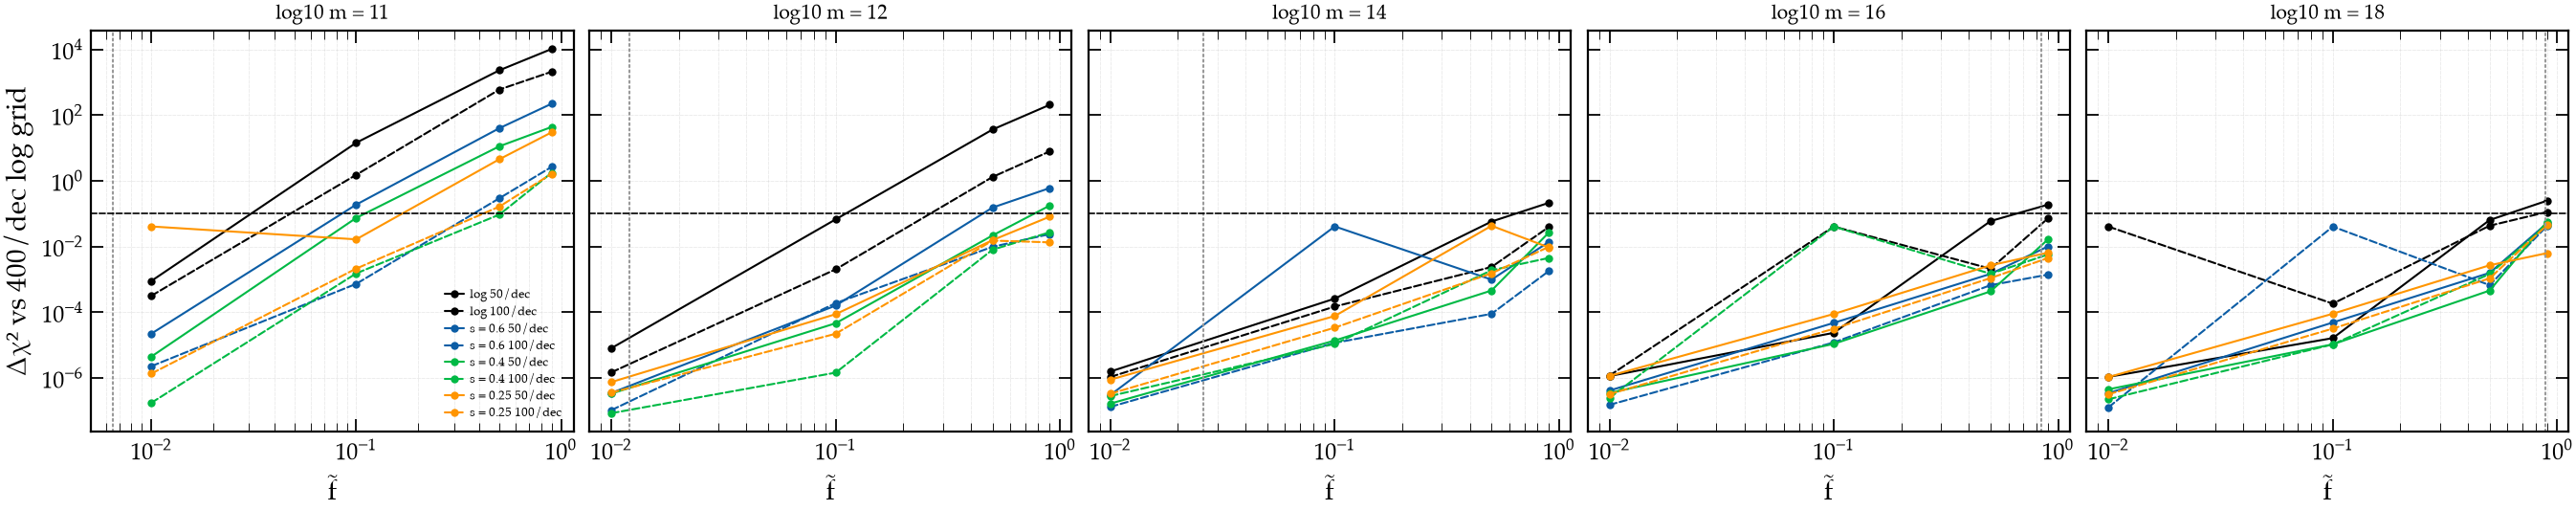

In [6]:
fig, axes = plt.subplots(1, len(MASSES), figsize=(3.6*len(MASSES), 3.6), sharey=True, constrained_layout=True)
for ax, lm in zip(axes, MASSES):
    for c, s in zip(('k', 'C0', 'C1', 'C2'), [1.0] + SHARES):
        for n, ls in zip(NODE_BINS, ('-', '--')):
            y = [max(compare(grid[(lm, ft, s, n)], ref[(lm, ft)])['total'], 1e-9) for ft in F_GRID]
            ax.loglog(F_GRID, y, ls, color=c, marker='o', ms=3, lw=1,
                      label='{} {}/dec'.format('log' if s == 1 else 's = {:g}'.format(s), n))
    if lm in F95:
        ax.axvline(F95[lm], color='0.6', ls=':', lw=1)
    ax.axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
    ax.set_title('log10 m = {:g}'.format(lm), fontsize=10)
    ax.set_xlabel('f̃')
    ax.grid(alpha=0.3, which='both')
axes[0].set_ylabel('Δχ² vs 400/dec log grid')
axes[0].legend(fontsize=6)
plt.show()

## 2. Success criteria

At equal node count, for each s:

- **gain:** the smallest Δχ²(log)/Δχ²(s) over the points where the log grid is above 0.1 (needs ≥ 10);
- **worse:** points where s exceeds the log grid by more than the 0.04 floor (needs none);
- **time:** median runtime ratio s/log (needs ≤ 1.1).

In [7]:
FLOOR = 0.04
for n in NODE_BINS:
    sub = cmp.xs(n, level='bins/dec')
    big = sub['log grid'] > DCHI2_TOL
    print('{}/decade: {} points with log-grid dchi2 > {:g}'.format(n, int(big.sum()), DCHI2_TOL))
    for s in SHARES:
        col = 's={:g}'.format(s)
        gain = (sub.loc[big, 'gain ' + col]).min() if big.any() else np.nan
        worse = sub.index[sub[col] > sub['log grid'] + FLOOR].tolist()
        tratio = sub['time ratio ' + col].median()
        print('  s = {:<5g} gain {:>8.3g} [{}]   worse: {} [{}]   time {:.2f} [{}]'.format(
            s, gain, 'PASS' if gain >= 10 else 'FAIL', worse if worse else 'none', 'FAIL' if worse else 'PASS',
            tratio, 'PASS' if tratio <= 1.1 else 'FAIL'))

50/decade: 8 points with log-grid dchi2 > 0.1
  s = 0.6   gain     4.89 [FAIL]   worse: [(14, 0.1)] [FAIL]   time 0.87 [PASS]
  s = 0.4   gain     4.38 [FAIL]   worse: none [PASS]   time 0.86 [PASS]
  s = 0.25  gain     22.8 [PASS]   worse: [(11, 0.01)] [FAIL]   time 0.87 [PASS]
100/decade: 6 points with log-grid dchi2 > 0.1
  s = 0.6   gain     2.69 [FAIL]   worse: [(18, 0.1)] [FAIL]   time 0.87 [PASS]
  s = 0.4   gain     2.45 [FAIL]   worse: none [PASS]   time 0.89 [PASS]
  s = 0.25  gain     2.52 [FAIL]   worse: none [PASS]   time 0.91 [PASS]


## Reading the result

- **Section 0:** at the default 71 nodes, s = 0.6 / 0.4 / 0.25 put 37 / 48 / 56 nodes inside the central 98% of
  births, against 17 for the even grid, and leave 23 / 15 / 10 after the births instead of 37.
- **Section 1, gains:** wherever the even grid's error was large, the born-fraction grids cut it by orders of
  magnitude at the same node count.
  - **Warm daughters:** gains of 50–2500×. 10¹² GeV, f̃ = 0.9: Δχ² 207 → 0.18 (s = 0.4) → 0.08 (s = 0.25).
    10¹¹ GeV, f̃ = 0.5: 2300 → 4.6 (s = 0.25).
  - **Cold daughters, f̃ = 0.5:** 0.06 → 0.0005–0.003.
  - **f̃ = 0.9 at 10¹⁴–10¹⁸ GeV:** 0.19–0.25 → 0.006–0.06.
- **Section 1, the floor:** below a few times 10⁻², the comparison stops being informative. 6 of the 120 new runs
  (and 3 of nb37's even-grid runs) show an isolated Δχ² ≈ 0.041. These are the spikes in the plot, they occur at
  any s and node count, and they are the bin-independent jump of nb33 and nb37. All shares give ≈ 0.045 at
  10¹⁸ GeV, f̃ = 0.9, 100/decade, so that reference itself may carry the jump.
- **Runtime:** the new grids are not slower. The median ratio to the even grid is 0.86–0.91, falling to 0.5 at
  10¹⁶ GeV and large f̃.
- **Abundance:** Ω_acc today moves by +1e-6 / +2.5e-5 / +6e-5 (s = 0.6 / 0.4 / 0.25, relative to the daughter
  density), from the thinner tails. This is negligible next to the perturbation errors removed.
- **Section 2, the spec's criteria as written:** no share passes all three at both node counts, but every failure
  sits at the floor.
  - **Gain ≥ 10:** missed at 10¹⁸ GeV, f̃ = 0.9 for s = 0.6 and 0.4 (gain 4–5, residual ≈ 0.05), and at
    100/decade for all shares (residuals ≈ 0.04).
  - **Worse:** each failure is a single 0.041 jump: (10¹⁴ GeV, f̃ = 0.1) for s = 0.6, (10¹¹ GeV, f̃ = 0.01) for
    s = 0.25, (10¹⁸ GeV, f̃ = 0.1, 100/decade) for s = 0.6.
  - **s = 0.25 at the default 50/decade** passes the gain (23×) and runtime criteria and fails "worse" by one
    floor jump.

**Recommendation:** s = 0.25. At the default 71 nodes it brings every tested point from 10¹² GeV up to
Δχ² ≤ 0.08, and every point from 10¹⁴ GeV up to ≤ 0.01 apart from floor jumps, at no extra cost. Large errors
remain only for the warmest daughters at large f̃ (10¹¹ GeV, f̃ ≥ 0.5), which also carry the `l_max_ncdm`
error of nb37 (2b). Before making it the default:

1. check other transitions (κ = 5, 30, 100 and other a_t, as in nb33). The map follows the births, so it should
   help most where nb33 failed at large κ;
2. regenerate the golden regression and rerun notebook 1;
3. understand the Δχ² ≈ 0.04 jumps, which are now the largest remaining numerical error.